##Условия задач

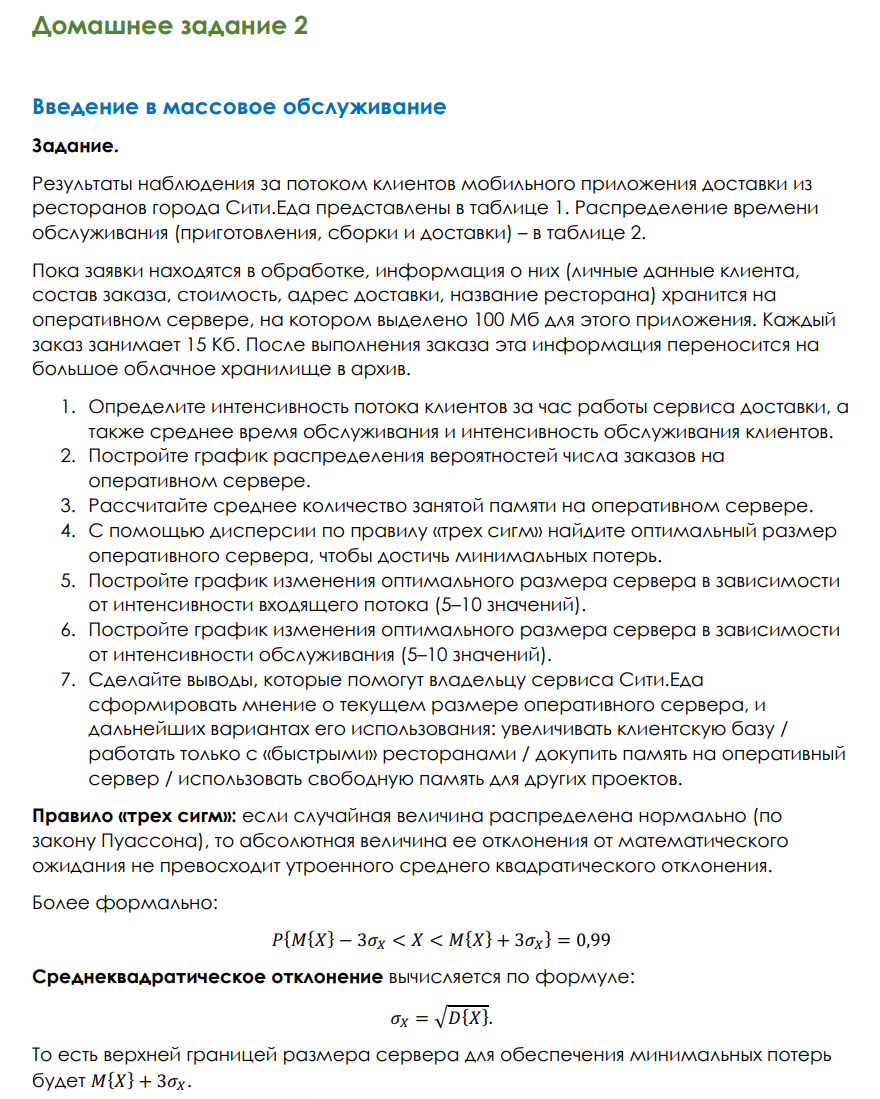

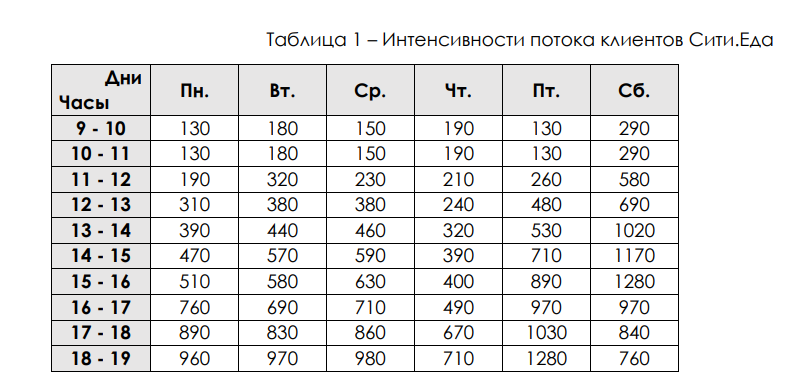

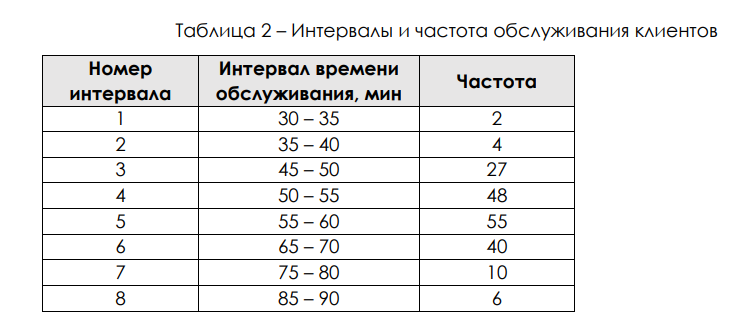

##Дано


In [ ]:
# Подключим библиотеки
# Создадим базу переменных для последующей работы
# А - Словарь: Интенсивность потока клиентов
# B - Словарь: Интервалы и частота орбслуживания клиентов
# C - Датафрейм: из A
# D - Датафрейм: из B

import numpy as np , pandas as pd , matplotlib.pyplot as plt
from scipy import stats

A = { 'Часы': ['9-10','10-11','11-12','12-13','13-14','14-15','15-16','16-17','17-18','18-19'],
      'Пн': [130,130,190,310,390,470,510,760,890,960],
      'Вт': [180,180,320,380,440,570,580,690,830,970],
      'Ср': [150,150,230,380,460,590,630,710,860,980],
      'Чт': [190,190,210,240,320,390,400,490,670,710],
      'Пт': [130,130,260,480,530,710,890,970,1030,1280],
      'Сб': [290,290,580,690,1020,1170,1280,970,840,760] }

B = { 'Номер интервала':['1','2','3','4','5','6','7','8'],
      'Интервал':['30-35','35-40','45-50','50-55','55-60','65-70','75-80','85-90'],
      'Частота':[2,4,27,48,55,40,10,6] }

C , D = pd.DataFrame(A) , pd.DataFrame(B)

##№1
Определим интенсивность потока клиентов за час работы сервиса доставки, а также среднее время обслуживания и интенсивность обслуживания клиентов.

In [ ]:
a = []
for i in ['Пн','Вт','Ср','Чт','Пт','Сб']:
    a.extend(C[i].values)
λ = np.mean(a)

b = []
for i in B['Интервал']:
    start, end = map(int, i.split('-'))
    b.append((start + end) / 2)
D['Середина'] = b
c = D['Частота'].sum()
c1 = np.sum (D['Середина'] * D['Частота']) / c # ср.время обслуживания
μ = 60/c1

print('Интенсивность потока клиентов =',round(λ,2),'кл/час')
print('Среднее время обслуживания =',round(c1,2),'мин')
print('Интенсивность обслуживания =',round(μ,2),'кл/час')

Интенсивность потока клиентов = 552.17 кл/час
Среднее время обслуживания = 58.23 мин
Интенсивность обслуживания = 1.03 кл/час


##№2
Построим график распределения вер.числа заказов на оперативном сервере.

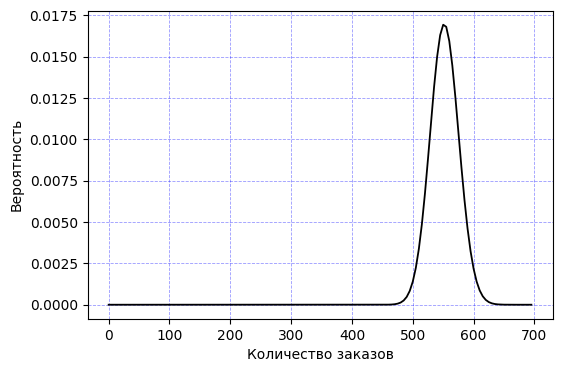

In [ ]:
d = np.arange(0, 700, 5)
d1 = stats.poisson.pmf(d, λ)
plt.figure(figsize=(6, 4))
plt.plot(d, d1, color='black',linewidth=1.3)
plt.xlabel('Количество заказов')
plt.ylabel('Вероятность')
plt.grid(linestyle ='--',color='blue',linewidth=0.6,alpha = 0.4)
plt.show()

##№3
Рассчитаем среднее количество занятой памяти на оперативном сервере.

In [ ]:
print('Среднее количество занятой памяти на оперативном сервере =',round(vzak := 15 * λ / 1024, 2),'Мб')

Среднее количество занятой памяти на оперативном сервере = 8.09 Мб


##№4
С помощью дисперсии по правилу «трех сигм» найдите оптимальный размер оперативного сервера, чтобы достичь минимальных потерь.

In [ ]:
mx , σ , p = λ , λ**0.5 , λ / μ
print('Оптимальный размер сервера =',round(opt_size :=  mx+σ*3,2),'Заказов,',round(opt_m := opt_size * 15/1024,2),'Мб')

Оптимальный размер сервера = 622.66 Заказов, 9.12 Мб


##№5
Постройте график изменения оптимального размера сервера в зависимости от интенсивности входящего потока (5–10 значений).

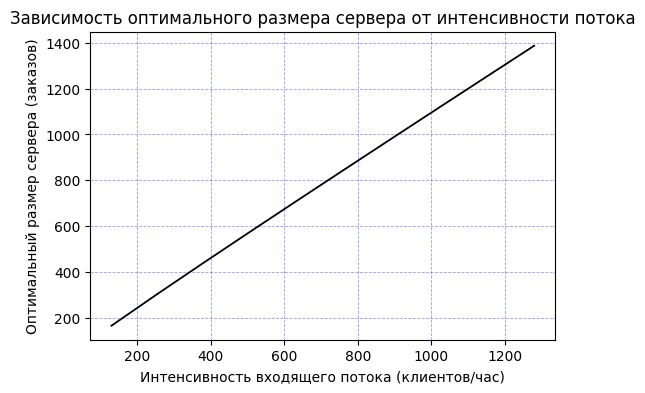

In [ ]:
λv, opt_sizes = np.linspace(130, 1280, 10),[]

for i in λv:
    opt_size = i + (i**0.5)*3
    opt_sizes.append(opt_size)

plt.figure(figsize=(6, 4))
plt.plot(λv, opt_sizes, color='black', linewidth=1.3)
plt.title('Зависимость оптимального размера сервера от интенсивности потока')
plt.xlabel('Интенсивность входящего потока (клиентов/час)')
plt.ylabel('Оптимальный размер сервера (заказов)')
plt.grid(linestyle ='--',color='blue',linewidth=0.6,alpha = 0.4)
plt.show()

##№6
Постройте график изменения оптимального размера сервера в зависимости от интенсивности обслуживания (5–10 значений).

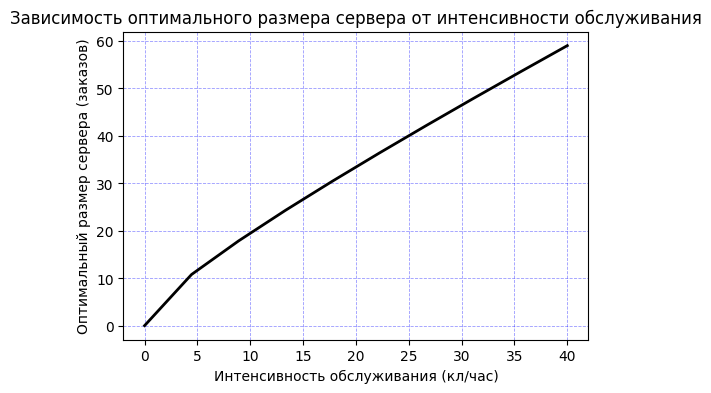

In [ ]:
μv, opt_sizes = np.linspace(0, 40, 10),[]

for i in μv:
    opt_size = i + (i**0.5)*3
    opt_sizes.append(opt_size)

plt.figure(figsize=(6, 4))
plt.plot(μv, opt_sizes , color='black', linewidth=2)
plt.title('Зависимость оптимального размера сервера от интенсивности обслуживания')
plt.xlabel('Интенсивность обслуживания (кл/час)')
plt.ylabel('Оптимальный размер сервера (заказов)')
plt.grid(linestyle ='--',color='blue',linewidth=0.6,alpha = 0.4)
plt.show()

## Выводы
Сделайте выводы, которые помогут владельцу сервиса Сити.Еда сформировать мнение о текущем размере оперативного сервера, и дальнейших вариантах его использования: увеличивать клиентскую базу / работать только с «быстрыми» ресторанами / докупить память на оперативный сервер / использовать свободную память для других проектов.

1. Общий объем сервера составляет 100 Мб, что в максимальном количестве заказов составляет 6826 заказов
2. Увеличивать клиентскую базу можно, т.к средний показатель загружености сервера показал, что текущей мощности хватит для и для дальнейшего увеличения заказов, но не более 6826
3. Работа только с «быстрыми» ресторанами позволит снизить серверную нагрузку
4. Докупить память на оперативный сервер понадобиться в случае увеличения обьемов заказов более 6826
5. Использовать свободную память для других проектов можно, что позволит повысить рентабельность основных средств.

--------------------------------------------------------

## Практические задачи из Лекции 3

# Задание 1

4


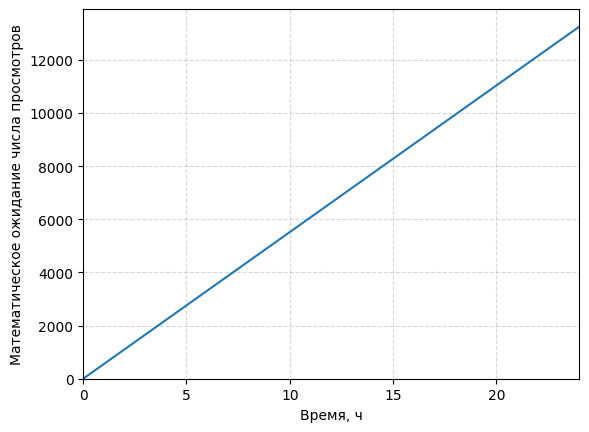

In [ ]:
import matplotlib.pyplot as plt

M_list, λ  = [λ * t for t in [i for i in range(25)]],4
print(λ)
plt.plot(M_list)
plt.xlabel('Время, ч')
plt.ylabel('Математическое ожидание числа просмотров')
plt.xlim(0,24)
plt.ylim(0,)
plt.grid(linestyle ='--', alpha = 0.5)
plt.show()

# Задание 2

In [ ]:
dt , S , M = [3,4,17],[10,5,1],0
for i in range(len(dt)):
    M += λ * dt[i] * S[i]
print(f'Ожидаемый доход: {M} у.е')

Ожидаемый доход: 268 у.е


# Задание 3

In [ ]:
# Т.к увеличение просмотров прямопропорционально влияет на увеличение дохода, то рекомедуеться следующее:
# 1. Организовать акцию преведи друга
# 2. Провести исследование рынка, выявить ключевых потребителей и организвать для них таргетированную рекламу
# 3. Увелисить обьем производства видеоконтента для  покрытия большего спроса

# Задание 4

In [ ]:
import numpy as np

max_intervals, max_duration, max_reward = 24,24,10 # Параметры можно менять: 1-24, 1-24, 1-10
best_income, best_params = 0,{}

for i in range(1, max_intervals + 1):
    for l in range(1, max_duration + 1):
        for k in range(1, max_reward + 1):
            if i * l <= 24:
                total_income = λ * i * l * k
                if total_income > best_income:
                    best_income = total_income
                    best_params = {'num_intervals': i ,'duration': l ,'reward': k }

print(f"Количество интервалов: {best_params['num_intervals']}")
print(f"Длина интервала: {best_params['duration']} ч")
print(f"Вознаграждение за просмотр: {best_params['reward']} y.e.")
print(f"Ожидаемый доход: {best_income:.2f} y.e.")

Количество интервалов: 1
Длина интервала: 24 ч
Вознаграждение за просмотр: 10 y.e.
Ожидаемый доход: 960.00 y.e.
